In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import warnings
from xarray.coding.times import SerializationWarning
import cftime
from scipy.optimize import curve_fit
import importlib
from sklearn.metrics import root_mean_squared_error as rmse

# my own functions
import Functions
from Functions import *

importlib.reload(Functions)

<module 'Functions' from '/nobackup/users/hartevel/data/Data_analysis/Functions.py'>

### Opening and slicing data

#### Opening and slicing data

In [11]:
warnings.simplefilter("ignore", SerializationWarning) # suppresses the warning that datetime does not work

def drop_duplicate_time(da, name="", verbose=True):
    """
    Remove duplicated time coordinates from a DataArray.
    Keeps the FIRST occurrence.
    """
    time = da.time

    # Boolean mask: True where time is NOT duplicated
    _, index = np.unique(time.values, return_index=True)
    index = np.sort(index)

    if verbose and len(index) < len(time):
        print(
            f"[INFO] Dropped {len(time) - len(index)} duplicate time steps from {name}"
        )

    return da.isel(time=index)


def align(tas, pr, prsn, verbose=True):

    # Remove duplicated time steps (before alignment!)
    tas  = drop_duplicate_time(tas,  name="tas",  verbose=verbose)
    pr   = drop_duplicate_time(pr,   name="pr",   verbose=verbose)
    prsn = drop_duplicate_time(prsn, name="prsn", verbose=verbose)

    # Align: keep only times present in ALL variables
    tas, pr, prsn = xr.align(tas, pr, prsn, join="inner")

    return tas, pr, prsn


def create_dictionary(monthly_dir, prsn_threshold = 1e-3, pr_threshold = 1e-3, snfr_threshold_snow = 1e-6, snfr_threshold_pr = 0, model = ''):
    
    scenarios = ['pi','2K','4K']
    
    raw_data_dictionary = create_dictionary_data(monthly_dir, 1, detrend = 'raw', model = model)
    
    for scenario in scenarios:
        raw_data_dictionary[scenario]['tas'], raw_data_dictionary[scenario]['pr'], raw_data_dictionary[scenario]['prsn'] = align(raw_data_dictionary[scenario]['tas'], raw_data_dictionary[scenario]['pr'], raw_data_dictionary[scenario]['prsn'])

    if model == 'CNRM':
        for parameter in ['tas','prsn','pr']:
            raw_data_dictionary['pi'][parameter] = raw_data_dictionary['pi'][parameter].isel(time = slice(60, None))

    data_len = min(len(raw_data_dictionary['pi']['tas'].time), 
               len(raw_data_dictionary['2K']['tas'].time), 
               len(raw_data_dictionary['4K']['tas'].time)) 

    print(data_len)

    for scenario in scenarios:
        raw_data_dictionary[scenario]['tas'] = raw_data_dictionary[scenario]['tas'].isel(time = slice(0,data_len))
        raw_data_dictionary[scenario]['pr'] = raw_data_dictionary[scenario]['pr'].isel(time = slice(0,data_len))
        raw_data_dictionary[scenario]['pr'] = raw_data_dictionary[scenario]['pr'].where(raw_data_dictionary[scenario]['pr'] > pr_threshold, 0) 
        raw_data_dictionary[scenario]['prsn'] = raw_data_dictionary[scenario]['prsn'].isel(time = slice(0,data_len))
        # raw_data_dictionary[scenario]['prsn'] = raw_data_dictionary[scenario]['prsn'].where(raw_data_dictionary[scenario]['pr'] > pr_threshold, 0) # this is to have the same mask for pr and prsn
        raw_data_dictionary[scenario]['prsn'] = raw_data_dictionary[scenario]['prsn'].where(raw_data_dictionary[scenario]['prsn'] > prsn_threshold, 0) # this is if I want to have seperate thresholds

        raw_data_dictionary[scenario]['snfr'] = snow_fraction(raw_data_dictionary[scenario]['prsn'], raw_data_dictionary[scenario]['pr'], snfr_threshold_snow, snfr_threshold_pr)
        
    return raw_data_dictionary

### Data processing functions

#### Removing seasonal cycle

In [22]:
def Remove_SeasCyc(data_array , plot = 0):
    t0 = data_array.time.values[0]
    new_data = []
    for month in range(1,13):
        month_data = data_array.sel(time=data_array['time'].dt.month ==month)
        month_mean = month_data.mean(dim = 'time')
        new_data.append(month_data-month_mean)

    if (data_array.time.dt.year[0] - data_array.time.dt.year[1]) == 0:
        year_mean = yearly_mean(data_array)
        mean = year_mean.mean(dim = 'time')
    else:
        mean = data_array.mean(dim = 'time')

    result = xr.concat(new_data, dim = 'time').sortby('time') + mean

    if plot == 1:
        plt.figure()
        
        if isinstance(t0, cftime.datetime):
            da = result.isel(lat=70, lon=330)
            da_original = data_array.isel(lat=70, lon=330)
            t = cftime.date2num(da.time.values, units="days since 0001-01-01")    
            plt.scatter(t, da.values, s=3, edgecolors = 'none', label = 'Seasonal cycle removed', c = 'm',)
            plt.scatter(t, da_original.values, s=3, edgecolors = 'none', label = 'Original data', c = 'black')          
        else:
            result.isel(lat = 70, lon = 330).plot.scatter(c = 'm', s = 3, edgecolors = 'none', label = 'Seasonal cycle removed')
            data_array.isel(lat = 70, lon = 330).plot.scatter(c = 'black', s = 3, edgecolors = 'none', label = 'original data')
    
        plt.legend()
        plt.title('Removal of seasonal cycle')
        plt.savefig('No_seasons_data_array.png')
        plt.show()

    return result

#### Detrending data

In [3]:
def detrend(data_array, plot = 0, lats = 20, lons = 3, snfr_threshold_snow = 0, snfr_threshold_pr = 0):

    if isinstance(data_array, (xr.DataArray, xr.Dataset)):      
        t0 = data_array.time.values[0]
        fit_params = data_array.polyfit(dim = 'time', deg = 1)
        fit = xr.polyval(data_array.time, fit_params.polyfit_coefficients)
        difference = data_array - fit
        
        if (fit.time.dt.year[0] - fit.time.dt.year[1]) == 0: # checks if it is a monthly array, then take year_mean
            year_mean = yearly_mean(fit, snfr_threshold_snow = snfr_threshold_snow, snfr_threshold_pr = snfr_threshold_pr)
            mean = year_mean.mean(dim = 'time')
        else:
            mean = fit.mean(dim = 'time')
            
        detrended_array = difference + mean
       
        if plot == 1:
            plt.figure()
            
            if isinstance(t0, cftime.datetime):
                t = cftime.date2num(detrended_array.time.values, units="days since 0001-01-01")    
                # plt.scatter(t, detrended_array.isel(lat = lats, lon = lons).values, c = 'm', s = 3, edgecolors = 'none', label = 'detrended data')
                plt.scatter(t, data_array.isel(lat = lats, lon = lons).values, c = 'black', s = 3, edgecolors = 'none', label = 'original data') 
                # plt.scatter(t, difference.isel(lat = lats, lon = lons).values, c = 'b', s = 3, edgecolors = 'none', label = 'difference original data and fit')
                plt.plot(t, fit.isel(lat = lats, lon = lons).values, c = 'red', label = 'fit')  
            else:
                # detrended_array.isel(lat = lats, lon = lons).plot.scatter(x = 'time', c = 'm', s = 3, edgecolors = 'none', label = 'detrended data')
                data_array.isel(lat = lats, lon = lons).plot.scatter(x = 'time', c = 'black', s = 3, edgecolors = 'none', label = 'original data')
                # difference.isel(lat = lats, lon = lons).plot.scatter(x = 'time', c = 'b', s = 3, edgecolors = 'none', label = 'difference original data and fit')
                fit.isel(lat = lats, lon = lons).plot(c = 'red', label = 'fit')
    
            plt.legend()
            plt.title('Visualisation of detrending')
            plt.savefig('detrended_data_array.png')
            plt.show()
            
        print(data_array.min().values, detrended_array.min().values)
        return detrended_array  

    elif isinstance(data_array, dict):

        if 'snfr'in data_array.keys():
            new_dict = {}

            for p in ['tas', 'prsn', 'pr']:
                new_dict[p] = detrend(data_array[p], plot, lats, lons, snfr_threshold_snow, snfr_threshold_pr)

            new_dict['snfr'] = snow_fraction(new_dict['prsn'], new_dict['pr'], snfr_threshold_snow, snfr_threshold_pr)  
            return new_dict

        else:
            return {k: detrend(v, plot, lats, lons, snfr_threshold_snow, snfr_threshold_pr) for k, v in data_array.items()}


    # --- lists (your variability output) ---
    elif isinstance(data_array, list):
        return [detrend(v, plot, lats, lons, snfr_threshold_snow, snfr_threshold_pr) for v in data_array]

    else:
        print('Data is not a dictionary, list, xarray or xr dataset. Nothing was changed.')
        return data_array


### Data processing

In [3]:
def save_dataset(dictionary, directory, detrend = 'detrended_', model = ''):

    if model == 'CNRM':
        base_dirs = {
            'pi': directory + '/PI',
            '2K': directory + '/GWL2',
            '4K': directory + '/GWL4'
        }
    else:
        base_dirs = {
            'pi': directory + '/pi_control_smhi',
            '2K': directory + '/gwl2p0_knmi',
            '4K': directory + '/gwl4p0_dmi'
        }

    variables = ['tas', 'prsn', 'pr', 'snfr']

    for experiment, base_dir in base_dirs.items():

        for var in variables:
            dictionary[experiment][var].to_dataset(name = var).to_netcdf(f'{base_dir}/{detrend}{var}.nc')


In [163]:
 
def data_processing_saving(directory, model):
    # Processing data
    data_dict = create_dictionary(directory, prsn_threshold = -1, pr_threshold = -1, model = model)
    sliced_data_dict = create_dictionary(directory, prsn_threshold = 1e-15, pr_threshold = 1e-15, model = model)  

    # detrended data
    # detrended_monthly = detrend(data_dict, snfr_threshold = 0)
    # detrended_monthly_sliced = detrend(sliced_data_dict)

    # yearly data
    yearly = yearly_mean(data_dict)
    sliced_yearly = yearly_mean(sliced_data_dict)

    # detrended yearly
    # detrended_yearly = detrend(yearly, snfr_threshold = 0)
    # sliced_detrended_yearly = detrend(sliced_yearly)

    # Saving data
    save_dataset(data_dict, directory, '', model)
    save_dataset(sliced_data_dict, directory, 'sliced_', model)
    # save_dataset(detrended_monthly, directory, 'detrended_', model)
    # save_dataset(detrended_monthly_sliced, directory, 'sliced_detrended', model)
    save_dataset(yearly, directory, 'yearly_', model)
    save_dataset(sliced_yearly, directory, 'yearly_sliced_', model)
    # save_dataset(detrended_yearly, directory, 'yearly_detrended_', model)
    # save_dataset(sliced_detrended_yearly, directory, 'yearly_sliced_detrended', model)   
    

In [164]:
EC_earth_dir_monthly = '/nobackup/users/hartevel/data/EC_earth/data'
UKESM_dir_monthly = '/nobackup/users/hartevel/data/UKESM/data/ukesm'
CNRM_dir_monthly = '/nobackup/users/hartevel/data/CNRM/CNRM'

# data_processing_saving(EC_earth_dir_monthly, 'EC-earth')
# data_processing_saving(UKESM_dir_monthly, 'UKESM')
data_processing_saving(CNRM_dir_monthly, 'CNRM')

[INFO] Dropped 12 duplicate time steps from tas
[INFO] Dropped 12 duplicate time steps from pr
[INFO] Dropped 12 duplicate time steps from prsn
[INFO] Dropped 12 duplicate time steps from tas
[INFO] Dropped 12 duplicate time steps from pr
[INFO] Dropped 12 duplicate time steps from prsn
[INFO] Dropped 12 duplicate time steps from tas
[INFO] Dropped 12 duplicate time steps from pr
[INFO] Dropped 12 duplicate time steps from prsn
2604
0.0
0.0
0.0
[INFO] Dropped 12 duplicate time steps from tas
[INFO] Dropped 12 duplicate time steps from pr
[INFO] Dropped 12 duplicate time steps from prsn
[INFO] Dropped 12 duplicate time steps from tas
[INFO] Dropped 12 duplicate time steps from pr
[INFO] Dropped 12 duplicate time steps from prsn
[INFO] Dropped 12 duplicate time steps from tas
[INFO] Dropped 12 duplicate time steps from pr
[INFO] Dropped 12 duplicate time steps from prsn
2604
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


### Comparing data sets

In [17]:
# def compare_datasets(directory, prsn_thresh, pr_thresh, snfr_thresh):
    # data_dict = create_dictionary(directory, prsn_threshold = -1, pr_threshold = -1, snfr_threshold = 0)
    # sliced_data_dict = create_dictionary(directory, prsn_threshold = prsn_thresh, pr_threshold = pr_thresh, snfr_threshold = snfr_thresh)
    
    # detrended_monthly = detrend(data_dict, snfr_threshold = 0)
    # detrended_monthly_sliced = detrend(sliced_data_dict, snfr_threshold = snfr_thresh)

def compare_datasets(detrended_monthly, detrended_monthly_sliced, timeslice = slice(100,150), threshold = 1e-10):

    prsn_sliced_2k = detrended_monthly_sliced['pi']['prsn'].isel(time = timeslice)
    pr_sliced_2k = detrended_monthly_sliced['pi']['pr'].isel(time = timeslice)
    snfr_sliced_2k = detrended_monthly_sliced['pi']['snfr'].isel(time = timeslice)
    tas_sliced_2k = detrended_monthly_sliced['pi']['tas'].isel(time = timeslice)

    prsn_2k = detrended_monthly['pi']['prsn'].isel(time = timeslice)
    pr_2k = detrended_monthly['pi']['pr'].isel(time = timeslice)
    snfr_2k = detrended_monthly['pi']['snfr'].isel(time = timeslice)
    tas_2k = detrended_monthly['pi']['tas'].isel(time = timeslice)

    # fig, ax = plt.subplots(1,2, sharey = True, figsize = (10,5))
    # ax[1].scatter(tas_sliced_2k, snfr_sliced_2k, s = 0.1, c = 'blue', alpha = 0.5)
    # ax[1].set_title(f'Threshold = {threshold}')
    # ax[0].scatter(tas_2k, snfr_2k, s = 0.1, c = 'blue', alpha = 0.5)
    # ax[0].set_title('No threshold')
    # ax[0].set_ylabel('Snowfall fraction')
    # ax[0].set_xlabel('Near surface air temperature [K]')
    # ax[1].set_xlabel('Near surface air temperature [K]')
    # plt.subplots_adjust(hspace=-0.01, wspace=0.1)
    
    # plt.show()



    # corr = xr.corr(prsn_2k, pr_2k, dim = 'time')
    # corr_sliced = xr.corr(prsn_sliced_2k, pr_sliced_2k, dim = 'time')

    # fig, ax = plt.subplots(1,2, sharey = True, figsize = (10,5))
    # ax[0].scatter(tas_2k.mean(dim = 'time'), corr, s = 0.1, c = 'blue', alpha = 0.5)
    # ax[0].set_title('No threshold')
    # ax[1].scatter(tas_sliced_2k.mean(dim = 'time'), corr_sliced, s = 0.1, c = 'blue', alpha = 0.5)
    # ax[1].set_title(f'Threshold = {threshold}')
    # ax[0].set_ylabel('Correlation Prsn, pr')
    # ax[0].set_xlabel('Near surface air temperature [K]')
    # ax[1].set_xlabel('Near surface air temperature [K]')
    # plt.subplots_adjust(hspace=-0.01, wspace=0.1)
    # for j in [0,1]:
    #     ax[j].axhline(y = 1, c = 'red', linewidth = 1, linestyle = '--')
    #     ax[j].axhline(y = 0, c = 'red', linewidth = 1, linestyle = '--')
    # plt.show()


    corr_prsn_snfr = xr.corr(prsn_2k, snfr_2k, dim = 'time') 
    corr_prsn_snfr_sliced = xr.corr(prsn_sliced_2k, snfr_sliced_2k, dim = 'time') 


    fig, ax = plt.subplots(1,2, sharey = True, figsize = (10,5))
    ax[0].scatter(tas_2k.mean(dim = 'time'), corr_prsn_snfr, s = 0.1, c = 'blue', alpha = 0.5)
    ax[0].set_title('No threshold')
    ax[1].scatter(tas_sliced_2k.mean(dim = 'time'), corr_prsn_snfr_sliced, s = 0.1, c = 'blue', alpha = 0.5)
    ax[1].set_title(f'Threshold = {threshold}')
    ax[0].set_ylabel('Correlation Prsn, snfr')
    ax[0].set_xlabel('Near surface air temperature [K]')
    ax[1].set_xlabel('Near surface air temperature [K]')
    plt.subplots_adjust(hspace=-0.01, wspace=0.1)
    for j in [0,1]:
        ax[j].axhline(y = 1, c = 'red', linewidth = 1, linestyle = '--')
        ax[j].axhline(y = 0, c = 'red', linewidth = 1, linestyle = '--')
    plt.show()

                # mask = (dictionary_variability[scenario]['prsn'][2] > 16 ) 
    # mask = (dictionary_variability[scenario]['tas'][1] > 285) & (dictionary_correlation[scenario]['prsn_snfr'] < 0.63)
    
    # year_mean_pr = yearly_mean(pr_2k)
    # year_mean_pr_sliced = yearly_mean(pr_sliced_2k)    
    # year_mean_prsn = yearly_mean(prsn_2k)
    # year_mean_prsn_sliced = yearly_mean(prsn_sliced_2k)
    # year_mean_snfr = snow_fraction(year_mean_prsn, year_mean_pr)
    # year_mean_snfr_sliced = snow_fraction(year_mean_prsn_sliced, year_mean_pr_sliced)
    # standard_2d_plot(year_mean_snfr.isel(time = 1))
    # standard_2d_plot(year_mean_snfr_sliced.isel(time = 1))



    pr_2k = pr_2k.stack(points = ('lon', 'lat', 'time'))
    pr_sliced_2k = pr_sliced_2k.stack(points = ('lon', 'lat', 'time'))
    print(len(pr_2k.where(pr_2k > 0, drop = True)))
    print(len(pr_sliced_2k.where(pr_sliced_2k > 0, drop = True)))

    

    # fig, ax = plt.subplots(1,2, sharey = True, figsize = (10,5))
    # ax[0].scatter(tas_sliced_2k, prsn_sliced_2k, s = 0.1, c = 'blue', alpha = 0.5)
    # ax[1].scatter(tas_2k, prsn_2k, s = 0.1, c = 'blue', alpha = 0.5)
    # ax[0].set_ylabel('Snowfall [mm/day]')
    # ax[0].set_xlabel('Near surface air temperature [K]')
    # ax[1].set_xlabel('Near surface air temperature [K]')
    # plt.subplots_adjust(hspace=-0.01, wspace=0.1)
    
    # plt.show()

    # fig, ax = plt.subplots(1,2, sharey = True, figsize = (10,5))
    # ax[0].scatter(tas_sliced_2k, pr_sliced_2k, s = 0.1, c = 'b', alpha = 0.5)
    # ax[1].scatter(tas_2k, pr_2k, s = 0.1, c = 'b', alpha = 0.5)
    # ax[0].set_ylabel('Total precipitation [mm/day]')
    # ax[0].set_xlabel('Near surface air temperature [K]')
    # ax[1].set_xlabel('Near surface air temperature [K]')
    # plt.subplots_adjust(hspace=-0.01, wspace=0.1)
    
    # plt.show()
    
    
        

In [18]:
EC_earth_dir_monthly = '/nobackup/users/hartevel/data/EC_earth/data'
UKESM_dir_monthly = '/nobackup/users/hartevel/data/UKESM/data/ukesm'
CNRM_dir_monthly = '/nobackup/users/hartevel/data/CNRM/CNRM'


data_dict = create_dictionary(CNRM_dir_monthly, prsn_threshold = -1, pr_threshold = -1, model = 'CNRM')

ECE_data_dict = create_dictionary(EC_earth_dir_monthly, prsn_threshold = -1, pr_threshold = -1, model = 'EC-Earth')

UK_data_dict = create_dictionary(UKESM_dir_monthly, prsn_threshold = -1, pr_threshold = -1, model = 'UKESM')

[INFO] Dropped 12 duplicate time steps from tas
[INFO] Dropped 12 duplicate time steps from pr
[INFO] Dropped 12 duplicate time steps from prsn
[INFO] Dropped 12 duplicate time steps from tas
[INFO] Dropped 12 duplicate time steps from pr
[INFO] Dropped 12 duplicate time steps from prsn
[INFO] Dropped 12 duplicate time steps from tas
[INFO] Dropped 12 duplicate time steps from pr
[INFO] Dropped 12 duplicate time steps from prsn
2604
0.0
0.0
0.0
3600
-0.0004785657
-0.00054584444
-0.0006593466
3000
0.0
0.0
0.0


In [19]:

prsn_threshold = 0.001
pr_threshold = 0.01

sliced_data_dict = create_dictionary(CNRM_dir_monthly, prsn_threshold = prsn_threshold, pr_threshold = pr_threshold, model = 'CNRM')

ECE_sliced_data_dict = create_dictionary(EC_earth_dir_monthly, prsn_threshold = prsn_threshold, pr_threshold = pr_threshold, model = 'EC-Earth')

UK_sliced_data_dict = create_dictionary(UKESM_dir_monthly, prsn_threshold = prsn_threshold, pr_threshold = pr_threshold, model = 'UKESM')

[INFO] Dropped 12 duplicate time steps from tas
[INFO] Dropped 12 duplicate time steps from pr
[INFO] Dropped 12 duplicate time steps from prsn
[INFO] Dropped 12 duplicate time steps from tas
[INFO] Dropped 12 duplicate time steps from pr
[INFO] Dropped 12 duplicate time steps from prsn
[INFO] Dropped 12 duplicate time steps from tas
[INFO] Dropped 12 duplicate time steps from pr
[INFO] Dropped 12 duplicate time steps from prsn
2604
0.0
0.0
0.0
3600
-0.0004785657
-0.00054584444
-0.0006593466
3000
0.0
0.0
0.0


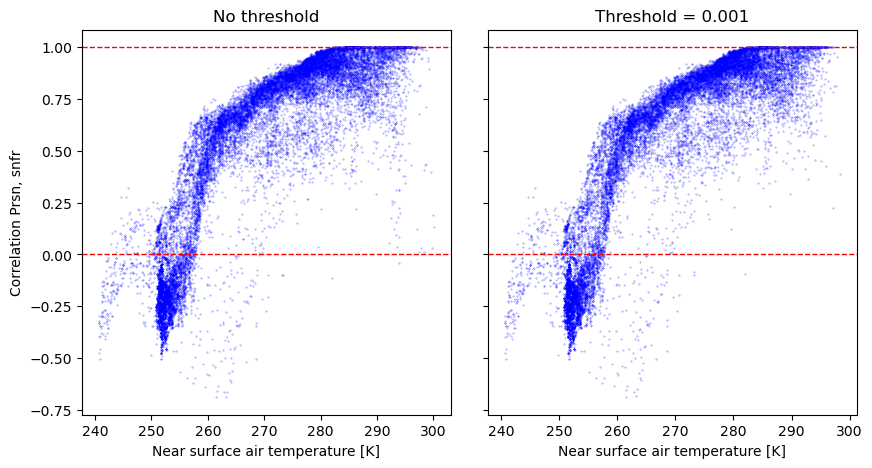

2916000
2805068


/usr/people/hartevel/miniconda3/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/people/hartevel/miniconda3/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


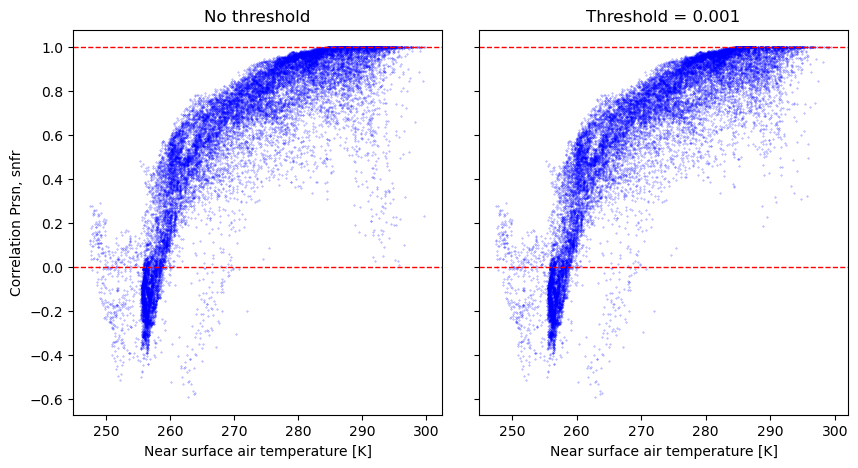

2521617
2456781


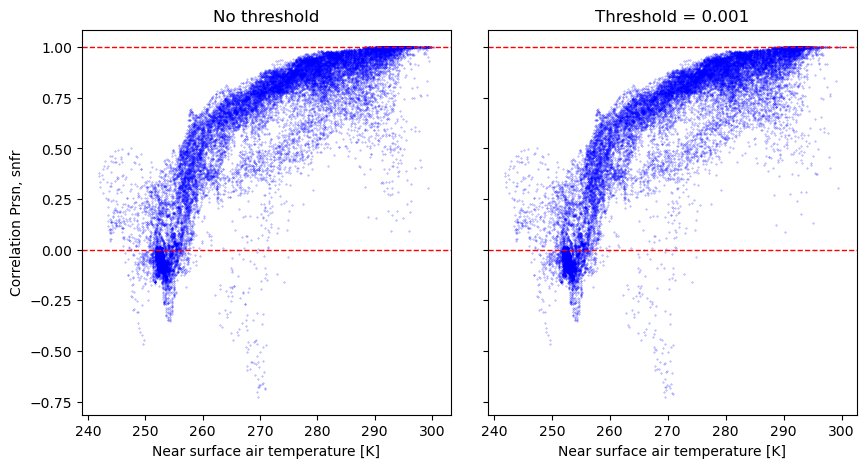

2590194
2513251


In [20]:
# compare_datasets(detrended_monthly, detrended_monthly_sliced)
compare_datasets(data_dict, sliced_data_dict, timeslice = slice(60,150), threshold = prsn_threshold)
# compare_datasets(data_dict, sliced_data_dict, timeslice = slice(59,150))
# compare_datasets(data_dict, sliced_data_dict, timeslice = slice(0,50))
compare_datasets(ECE_data_dict, ECE_sliced_data_dict, timeslice = slice(70,150), threshold = prsn_threshold)
compare_datasets(UK_data_dict, UK_sliced_data_dict, timeslice = slice(70,150), threshold = prsn_threshold)
# compare_datasets(detrended_monthly, strongly_sliced_detrended)

# for n in range(0, len(data_dict['pi']['tas'].time)-200, 200):
#     compare_datasets(data_dict, sliced_data_dict, timeslice = slice(n,n+200))